In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nice
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully!')


Libraries loaded successfully!


In [3]:
# Load the CSV file
df = pd.read_csv('hr_attrition_dataset.csv')

# Preview the first 5 rows
df.head()

,Age,Attrition,Department,JobRole,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,EducationField,MaritalStatus,PerformanceRating
0,26,Yes,Research & Development,Research Scientist,5764,1,1,4,No,11,Marketing,Single,3
1,32,Yes,Human Resources,Human Resources,6446,1,2,2,No,5,Life Sciences,Divorced,3
2,33,Yes,Research & Development,Research Director,3390,3,3,4,Yes,6,Technical Degree,Single,3
3,26,Yes,Sales,Sales Executive,5930,0,4,4,No,3,Medical,Divorced,3
4,27,Yes,Research & Development,Research Director,4532,4,1,4,Yes,9,Medical,Divorced,3


In [4]:
# How many rows and columns?
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print()

# Column names
print('Columns in our dataset:')
print(df.columns.tolist())

Rows: 1470
Columns: 13

Columns in our dataset:
['Age', 'Attrition', 'Department', 'JobRole', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance', 'OverTime', 'DistanceFromHome', 'EducationField', 'MaritalStatus', 'PerformanceRating']


In [5]:
# Are there any empty/null values?
print('Missing values per column:')
print(df.isnull().sum())


Missing values per column:
Age                  0
Attrition            0
Department           0
JobRole              0
MonthlyIncome        0
YearsAtCompany       0
JobSatisfaction      0
WorkLifeBalance      0
OverTime             0
DistanceFromHome     0
EducationField       0
MaritalStatus        0
PerformanceRating    0
dtype: int64


In [6]:
# Count how many left vs stayed
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100

print(f'Total Employees  : {len(df)}')
print(f'Employees Stayed : {attrition_counts["No"]}')
print(f'Employees Left   : {attrition_counts["Yes"]}')
print(f'Attrition Rate   : {attrition_rate:.1f}%')

Total Employees  : 1470
Employees Stayed : 1005
Employees Left   : 465
Attrition Rate   : 31.6%


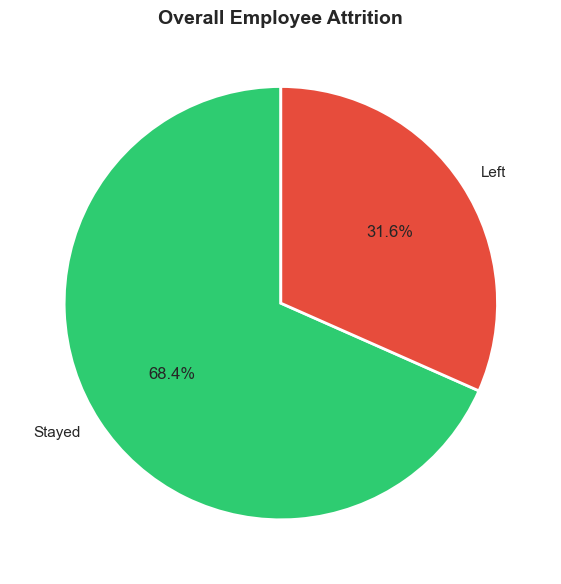

In [7]:
# Visualize attrition as a pie chart
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    attrition_counts,
    labels=['Stayed', 'Left'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Overall Employee Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Attrition rate per department
dept_attr = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).reset_index()
dept_attr.columns = ['Department', 'Attrition Rate (%)']
dept_attr = dept_attr.sort_values('Attrition Rate (%)', ascending=False)

print(dept_attr)

               Department  Attrition Rate (%)
2                   Sales                36.8
1  Research & Development                30.0
0         Human Resources                26.3


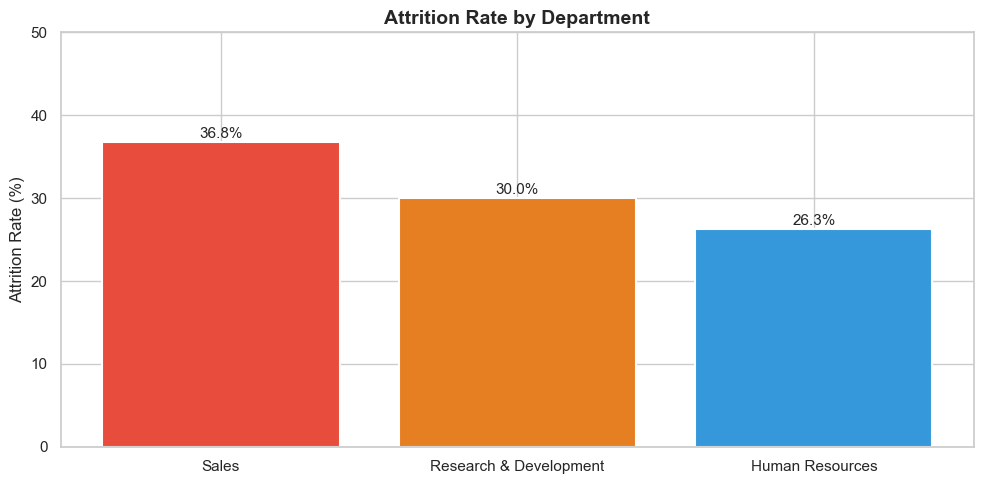

In [9]:
fig, ax = plt.subplots()
bars = ax.bar(
    dept_attr['Department'],
    dept_attr['Attrition Rate (%)'],
    color=['#e74c3c', '#e67e22', '#3498db'],
    edgecolor='white', linewidth=1.5
)
ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, 50)

# Add % labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
# Create age groups
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[18, 25, 35, 45, 55, 60],
                         labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# Attrition rate per age group
age_attr = df.groupby('AgeGroup', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).reset_index()
age_attr.columns = ['Age Group', 'Attrition Rate (%)']

print(age_attr)

  Age Group  Attrition Rate (%)
0     18-25                35.2
1     26-35                34.2
2     36-45                30.7
3     46-55                27.9
4       55+                22.7


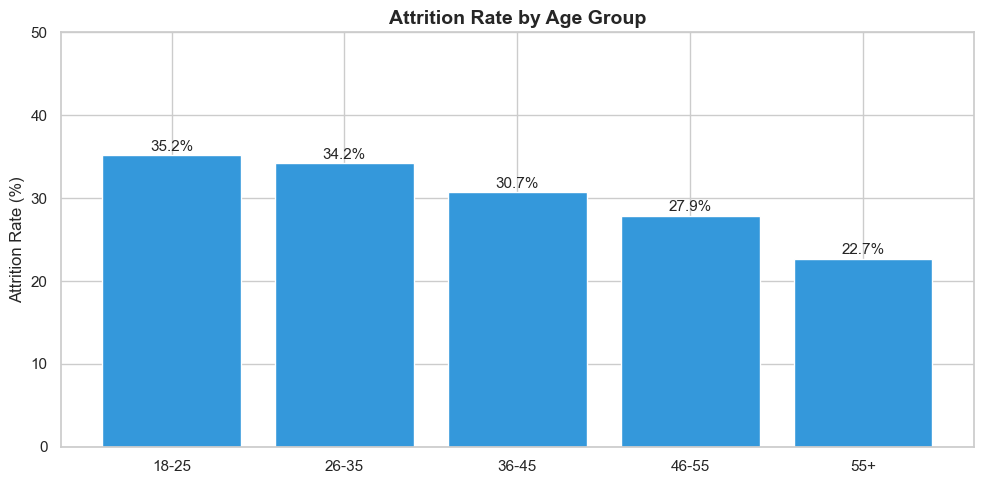

In [11]:
fig, ax = plt.subplots()
ax.bar(age_attr['Age Group'],
       age_attr['Attrition Rate (%)'],
       color='#3498db', edgecolor='white')
ax.set_title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, 50)

for i, row in age_attr.iterrows():
    ax.text(i, row['Attrition Rate (%)'] + 0.5,
            f"{row['Attrition Rate (%)']:.1f}%",
            ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
# Attrition rate for overtime vs no overtime
ot_attr = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).reset_index()
ot_attr.columns = ['OverTime', 'Attrition Rate (%)']

print(ot_attr)

  OverTime  Attrition Rate (%)
0       No                28.5
1      Yes                40.2


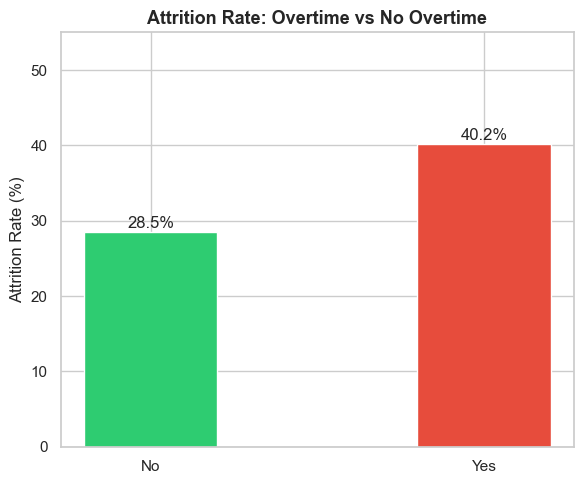

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(ot_attr['OverTime'],
       ot_attr['Attrition Rate (%)'],
       color=['#2ecc71', '#e74c3c'],
       edgecolor='white', width=0.4)
ax.set_title('Attrition Rate: Overtime vs No Overtime',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, 55)

for i, row in ot_attr.iterrows():
    ax.text(i, row['Attrition Rate (%)'] + 0.5,
            f"{row['Attrition Rate (%)']:.1f}%",
            ha='center', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# Create salary bands
df['SalaryBand'] = pd.cut(df['MonthlyIncome'],
                           bins=[0, 3000, 6000, 10000, 20000],
                           labels=['< $3K', '$3K–$6K', '$6K–$10K', '$10K+'])

# Attrition rate per salary band
sal_attr = df.groupby('SalaryBand', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).reset_index()
sal_attr.columns = ['Salary Band', 'Attrition Rate (%)']

print(sal_attr)

  Salary Band  Attrition Rate (%)
0       < $3K                41.7
1     $3K–$6K                29.0
2    $6K–$10K                31.1
3       $10K+                27.2


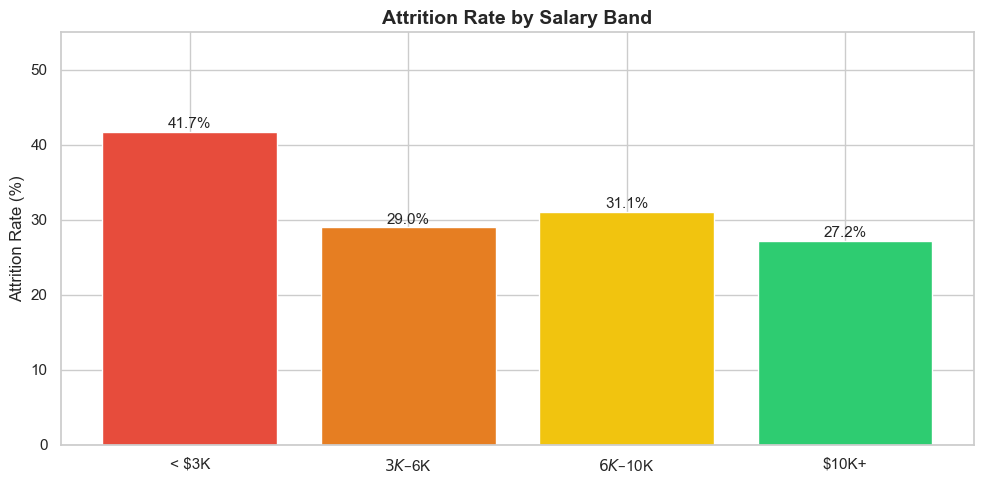

In [15]:
fig, ax = plt.subplots()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
ax.bar(sal_attr['Salary Band'],
       sal_attr['Attrition Rate (%)'],
       color=colors, edgecolor='white')
ax.set_title('Attrition Rate by Salary Band',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, 55)

for i, row in sal_attr.iterrows():
    ax.text(i, row['Attrition Rate (%)'] + 0.5,
            f"{row['Attrition Rate (%)']:.1f}%",
            ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
# Attrition rate per satisfaction level
sat_attr = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).reset_index()
sat_attr.columns = ['Job Satisfaction', 'Attrition Rate (%)']

print(sat_attr)

   Job Satisfaction  Attrition Rate (%)
0                 1                37.2
1                 2                39.9
2                 3                28.9
3                 4                26.5


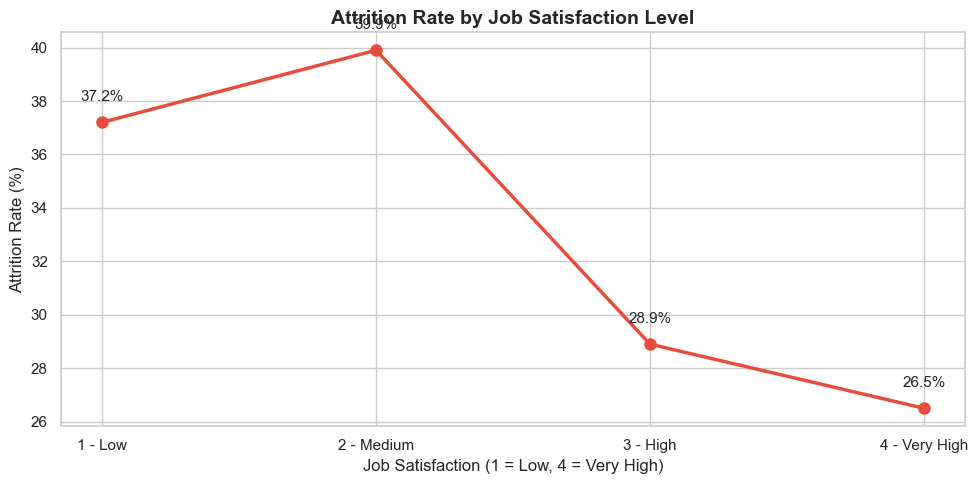

In [17]:
fig, ax = plt.subplots()
ax.plot(sat_attr['Job Satisfaction'],
        sat_attr['Attrition Rate (%)'],
        marker='o', linewidth=2.5,
        color='#e74c3c', markersize=8)

ax.set_title('Attrition Rate by Job Satisfaction Level',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Job Satisfaction (1 = Low, 4 = Very High)')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['1 - Low', '2 - Medium', '3 - High', '4 - Very High'])

# Add value labels on each point
for _, row in sat_attr.iterrows():
    ax.text(row['Job Satisfaction'],
            row['Attrition Rate (%)'] + 0.8,
            f"{row['Attrition Rate (%)']:.1f}%",
            ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [20]:
# Create tenure bands
df['TenureBand'] = pd.cut(df['YearsAtCompany'],
                           bins=[-1, 2, 5, 10, 20, 40],
                           labels=['0-2 yrs', '3-5 yrs', '6-10 yrs',
                                   '11-20 yrs', '20+ yrs'])

# Attrition rate per tenure band
tenure_attr = df.groupby('TenureBand', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).round(1).reset_index()
tenure_attr.columns = ['Tenure', 'Attrition Rate (%)']

print(tenure_attr)

      Tenure  Attrition Rate (%)
0    0-2 yrs                38.9
1    3-5 yrs                27.5
2   6-10 yrs                26.9
3  11-20 yrs                28.6
4    20+ yrs                27.5


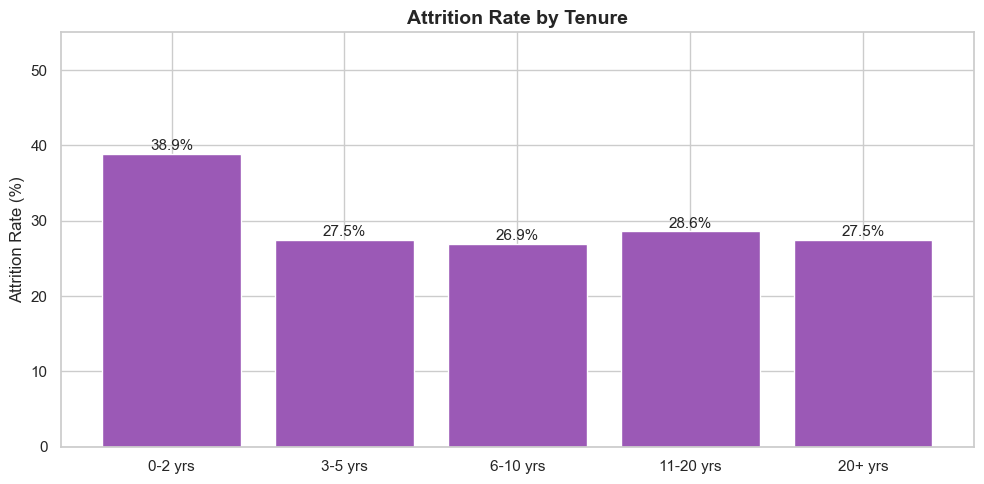

In [21]:
fig, ax = plt.subplots()
ax.bar(tenure_attr['Tenure'],
       tenure_attr['Attrition Rate (%)'],
       color='#9b59b6', edgecolor='white')
ax.set_title('Attrition Rate by Tenure',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, 55)

for i, row in tenure_attr.iterrows():
    ax.text(i, row['Attrition Rate (%)'] + 0.5,
            f"{row['Attrition Rate (%)']:.1f}%",
            ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [23]:
print('=' * 55)
print('   HR ANALYTICS — KEY FINDINGS SUMMARY')
print('   KPMG People & Change Advisory')
print('=' * 55)

rate = (df['Attrition'] == 'Yes').mean() * 100
print(f'\n1. Overall Attrition Rate: {rate:.1f}%')
print('   Industry benchmark is ~15%.')
print('   This organisation is at HIGH RISK.')

top_dept = dept_attr.iloc[0]
print(f"\n2. Highest Risk Department: {top_dept['Department']}")
print(f"   Attrition Rate: {top_dept['Attrition Rate (%)']:.1f}%")

ot_yes = ot_attr[ot_attr['OverTime']=='Yes']['Attrition Rate (%)'].values[0]
ot_no  = ot_attr[ot_attr['OverTime']=='No']['Attrition Rate (%)'].values[0]
print(f'\n3. Overtime Impact:')
print(f'   With Overtime    : {ot_yes:.1f}% attrition')
print(f'   Without Overtime : {ot_no:.1f}% attrition')

low_sal = sal_attr[sal_attr['Salary Band']=='< $3K']['Attrition Rate (%)'].values[0]
print(f'\n4. Low Salary (<$3K) Attrition: {low_sal:.1f}%')
print('   Compensation is a key driver of attrition.')

young = age_attr[age_attr['Age Group']=='18-25']['Attrition Rate (%)'].values[0]
print(f'\n5. Young Employees (18-25) Attrition: {young:.1f}%')
print('   Early-career employees need stronger retention.')

new_join = tenure_attr[tenure_attr['Tenure']=='0-2 yrs']['Attrition Rate (%)'].values[0]
print(f'\n6. New Joiners (0-2 yrs) Attrition: {new_join:.1f}%')
print('   Onboarding programs need urgent improvement.')

print('\n' + '=' * 55)
print('RECOMMENDATIONS:')
print('  - Reduce mandatory overtime in Sales department')
print('  - Review salary benchmarks for <$3K band')
print('  - Introduce mentorship for employees aged 18-25')
print('  - Strengthen onboarding for first 2 years')
print('  - Run quarterly pulse surveys on job satisfaction')
print('=' * 55)

   HR ANALYTICS — KEY FINDINGS SUMMARY
   KPMG People & Change Advisory

1. Overall Attrition Rate: 31.6%
   Industry benchmark is ~15%.
   This organisation is at HIGH RISK.

2. Highest Risk Department: Sales
   Attrition Rate: 36.8%

3. Overtime Impact:
   With Overtime    : 40.2% attrition
   Without Overtime : 28.5% attrition

4. Low Salary (<$3K) Attrition: 41.7%
   Compensation is a key driver of attrition.

5. Young Employees (18-25) Attrition: 35.2%
   Early-career employees need stronger retention.

6. New Joiners (0-2 yrs) Attrition: 38.9%
   Onboarding programs need urgent improvement.

RECOMMENDATIONS:
  - Reduce mandatory overtime in Sales department
  - Review salary benchmarks for <$3K band
  - Introduce mentorship for employees aged 18-25
  - Strengthen onboarding for first 2 years
  - Run quarterly pulse surveys on job satisfaction
